In [1]:
from SpikingNN.Izh_net import *
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

In [2]:
class Var_Limb(Net_Limb_connect):

    def __init__(self, **kwargs):
        """
        Реализация соединения в единую систему 
        именованые ардгументы:

        Network - объект класса Network
        Limb - объект класса Afferented_Limb или Simple_Afferented_Limb
        """
        super().__init__(**kwargs)
        self.names = {
            "neurons": self.net.names,
            "muscles": ["Flexor", "Extensor"],
            "afferents": [
                # Flexor sensors
                "Ia_Flex",
                "II_Flex", 
                "Ib_Flex",
                # Extensor sensors
                "Ia_Ext",
                "II_Ext",
                "Ib_Ext"
            ]
            
        }

    # Vaiances of network params

    # inherit from NameNetwork
    def set_weights_by_names(self, *args, **kwargs):
        """
        Change weight of connections by names of neurons
        inherit from NameNetwork

        exec method of self.net.set_weights_by_names
        Params:
        source_name(str)
        target_name(str)
        new_weight(float)
        """
        try:
            self.net.set_weights_by_names(*args, **kwargs)
        except AttributeError:
            print("Ошибка: такого метода нет!")

    @property
    def SynapticWeights(self):
        return self.net.W

    @property
    def SynapticRelaxation(self):
        return self.net.tau_syn

    @property
    def AfferentWeights(self):
        return self.net.Q_aff

    def set_afferents_by_names(            
            self,
            afferent_name,
            neuron_name,
            new_weight):
        """
        Change weight of connections by names of afferents and neurons

        Params:
        source_name(str)
        target_name(str)
        new_weight(float)
        """
        try:
            afferent_idx = self.names["afferents"].index(afferent_name)
            neuron_idx = self.names["neurons"].index(neuron_name)
            self.net.Q_aff[afferent_idx, neuron_idx] = new_weight
            return True
        except ValueError:
            return False

    def set_muscle_params(self,
                          muscle_name,
                          **params
                         ):
        if muscle_name == "Flexor":
            self.Limb.Flexor.set_params(**params)
        elif muscle_name == "Extensor":
            self.Limb.Extensor.set_params(**params)
        else:
            print(f"Мышца с именем \"{muscle_name}\" не найдена...")
            

    
    
    

(4, 2)
['CH', 'FS', 'CH', 'FS']
[0.001 0.1   0.001 0.1  ] [0.2 0.2 0.2 0.2] [-50. -65. -50. -65.] [2. 2. 2. 2.]
[[0.05 0.05 0.05 0.05]
 [0.05 0.05 0.05 0.05]
 [0.05 0.05 0.05 0.05]
 [0.05 0.05 0.05 0.05]]
[[ 0.   0.   0.  -1.1]
 [ 1.7  0.   0.   0. ]
 [ 0.  -1.1  0.   0. ]
 [ 0.   0.   1.7  0. ]]
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

____________________________
set_afferents_by_names TEST
OK

____________________________
set_weights_by_names TEST
OK

____________________________
set_muscle_params TEST
OK

____________________________
simulation test


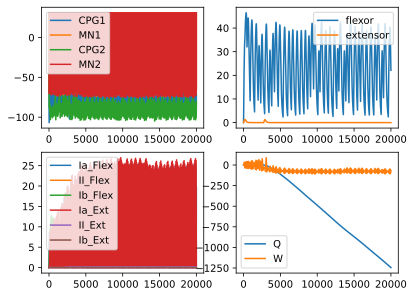

In [3]:
def test_Var_Limb():
    Q_app = np.array([
            [1, 0],
            [0, 0],
            [0, 1],
            [0, 0]
        ])
    print(Q_app.shape)
    Q_aff = 1*np.random.rand(4, 6)
    P = np.array([
            [1, 0, 0, 0],
            [0, 0, 1, 0]
        ])
    names = ["CPG1", "MN1", "CPG2", "MN2"]
    types = ['CH', 'FS', 'CH', 'FS']
    print(types)
    # Create params' array from neurons
    A, B, C, D = types2params(types)
    A[0] = 0.001
    A[2] = 0.001
    print(A, B, C, D)
    net = Izhikevich_IO_Network(input_size = 2, output_size = 2, 
                                afferent_size = 6,
                                N=4, Q_app = Q_app,
                                names = names,
                                Q_aff = Q_aff , P = P)
    
    net.set_params(a=A, b=B, c=C, d=D) 
    # Neuron_weigths
    W = [
            [0, 0, 0, -1.1],
            [1.7, 0, 0, 0],
            [0, -1.1, 0, 0],
            [0, 0, 1.7, 0]
        ]
    
    N=4
    net.M = np.ones((N, N))
    net.set_weights(W)
    tau_syn = 20*np.ones((N, N))
    net.set_synaptic_relax_constant(tau_syn)
    print(net.tau_syn)
    print(net.W)
    print(net.M)
    
    # Limb settings
    flexor = SimpleAdaptedMuscle(w = 0.5, N=2)
    extensor = SimpleAdaptedMuscle(w = 0.4, N=2)
    Limb = OneDOFLimb(q0=np.pi/2+0.4, b=0.001, a1 = 0.4,
                      a2= 0.05, m=0.3, l=0.3)
    AL = Afferented_Limb(
                Limb = Limb,
                Flexor = flexor,
                Extensor = extensor
            )

    # Creating all system
    sys = Var_Limb(Network=net,
                           Limb = AL)

    print("")
    print("____________________________")
    print("set_afferents_by_names TEST")
    sys.set_afferents_by_names("Ia_Flex", "CPG1", 1)
    print("OK")

    print("")
    print("____________________________")
    print("set_weights_by_names TEST")
    sys.set_weights_by_names("CPG1", "MN1", 0.4)
    print("OK")

    print("")
    print("____________________________")
    print("set_muscle_params TEST")
    sys.set_muscle_params("Flexor", A = 0.4)
    print("OK")



    print('')
    print("____________________________")
    print("simulation test")
    T = np.linspace(0, 20000, 50000)
    I = np.zeros(2)
    I[0] = 5
    I[1] = 5
    input = lambda t: (I)
    V = np.zeros((len(T), N))
    F_flex = np.zeros(len(T))
    F_ext = np.zeros(len(T))
    Afferents = np.zeros((len(T), 6))
    Q = np.zeros(len(T))
    W = np.zeros(len(T))
    dt = T[1] - T[0]
    for i, t in enumerate(T):
        V[i] = sys.net.V_prev
        F_flex[i] = sys.F_flex
        F_ext[i] = sys.F_ext
        Afferents[i] = sys.Limb.output
        Q[i] = sys.q
        W[i] = sys.w
        sys.step(dt = dt, Iapp = input(t))

    plt.figure()
    plt.subplot(221)
     
    for i in range(N):
        plt.plot(T, V[:, i], label=f"{sys.net.names[i]}")
    plt.legend()

    plt.subplot(222)
    plt.plot(T, F_flex, label='flexor')
    plt.plot(T, F_ext, label='extensor')
    plt.legend()

    plt.subplot(223)
    aff_types = sys.names['afferents']
    for i in range(6):
        plt.plot(T, Afferents[:, i], label=aff_types[i])
    plt.legend()

    plt.subplot(224)
    plt.plot(T, Q, label="Q")
    plt.plot(T, W, label='W')
    plt.legend()
    plt.show()

test_Var_Limb()

In [4]:
import numpy as np
from Izh_net import *
def Rybak2002_Mask():
    # Setting network connections' Mask like scheme(fig. 2)
    M = np.array([
    # source neuron number
    #  0     1     2     3     4     5     6     7     8     9    10    11     target neuron
     [ 0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.],  # CPG_IN_Flex
     [-1.,   0.,   0.,   0.,   0.,   0.,   0.,  -1.,   0.,   0.,   0.,   0.],  # CPG_N_Flex
     [ 0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  -1.,   0.,   0.,   0.],  # Ib_IN_Flex
     [ 0.,   1.,   0.,   0.,   0.,  -1.,   0.,   0.,   0.,  -1.,   0.,   0.],  # Ia_IN_Flex
     [ 0.,   1.,  -1.,   0.,   0.,  -1.,   0.,   0.,   0.,  -1.,   0.,   0.],  # MN_Flex
     [ 0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,  -1.],  # R_Flex
    
    # Extensor module
     [ 0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],  # CPG_IN_Ext
     [ 0.,  1.,   0.,   0.,   0.,   0.,  -1.,   0.,   0.,   0.,   0.,   0.],  # CPG_N_Ext
     [ 0.,   0.,  -1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],  # Ib_IN_Ext
     [ 0.,   0.,   0.,  -1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,  -1.],  # Ia_IN_Ext
     [ 0.,   0.,   0.,  -1.,   0.,   0.,   0.,   1.,  -1.,   0.,   0.,  -1.],  # MN_Ext
     [ 0.,   0.,   0.,   0.,   0.,  -1.,   0.,   0.,   0.,   0.,   1.,   0.]   # R_Ext
    ])
    return M



def Rybak2002_TAU(**kwargs):
    # Settings of synaptic relaxation constants
    ex_tau = kwargs.get('exitatory_tau', 10)
    in_tau = kwargs.get('inhibitory_tau', 20)
    tau_syn = np.array([
    # source neuron number
    # 0      1      2      3      4      5      6      7       8       9      10      11        Target neuron
     [1.,    1.,    1.,    1.,    1.,    1.,    1.,    1      ,1.,     ex_tau,     1.,     1.],  # CPG_IN_Flex
     [in_tau,1.,    1.,    1.,    1.,    1.,    1.,    in_tau,1.,     1.,     1.,     1.],      # CPG_N_Flex
     [1.,    1.,    1.,    1.,    1.,    1.,    1.,    1.,    in_tau, 1.,     1.,     1.],      # Ib_IN_Flex
     [1.,    ex_tau,1.,    1.,    1.,    in_tau,1.,    1.,    1.,     in_tau, 1.,     1.],      # Ia_IN_Flex
     [1.,    ex_tau,in_tau,1.,    1.,    in_tau,1.,    1.,    1.,     in_tau, 1.,     1.],      # MN_Flex
     [1.,    1.,    1.,    1.,    ex_tau,1.,    1.,    1.,    1.,     1.,     1.,     in_tau],  # R_Flex
    
    # Extensor module
     [1.,    1.,    1.,    ex_tau,1.,    1.,    1.,    1.,    1.,    1.,     1.,     1.],       # CPG_IN_Ext
     [1.,    in_tau,1.,    1.,    1.,    1.,    in_tau,1.,    1.,    1.,     1.,     1.],       # CPG_N_Ext
     [1.,    1.,    in_tau,1.,    1.,    1.,    1.,    1.,    1.,    1.,     1.,     1.],       # Ib_IN_Ext
     [1.,    1.,    1.,    in_tau,1.,    1.,    1.,    ex_tau,1.,    1.,     1.,     ex_tau],   # Ia_IN_Ext
     [1.,    1.,    1.,    in_tau,1.,    1.,    1.,    ex_tau,in_tau,1.,     1.,     in_tau],   # MN_Ext
     [1.,    1.,    1.,    1.,    1.,    in_tau,1.,    1.,    1.,    1.,     ex_tau, 1.]        # R_Ext
    ])
    return tau_syn

def Rybak2002_Weights(**kwargs):
    # Settings of synaptic weights
    ex_w = kwargs.get('exitatory_w', 0.1)
    in_w = kwargs.get('inhibitory_w', -0.1)
    W = np.array([
    # source neuron number
    #  0      1      2      3      4      5      6      7      8      9     10     11      Target neuron
     [ 0.,    0.,    0.,    0.,    0.,    0.,    0.,    0,   0.,    ex_w,    0.,    0.],   # CPG_IN_Flex
     [in_w,   0.,    0.,    0.,    0.,    0.,    0.,  in_w,   0.,    0.,    0.,    0.],    # CPG_N_Flex
     [ 0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,  in_w,   0.,    0.,    0.],    # Ib_IN_Flex
     [ 0.,  ex_w,    0.,    0.,    0.,  in_w,    0.,    0.,    0.,  in_w,   0.,    0.],    # Ia_IN_Flex
     [ 0.,  ex_w,  in_w,    0.,    0.,  in_w,    0.,    0.,    0.,  in_w,   0.,    0.],    # MN_Flex
     [ 0.,    0.,    0.,    0.,  ex_w,    0.,    0.,    0.,    0.,    0.,    0.,  in_w],   # R_Flex
    
    # Extensor module
     [ 0.,    0.,    0.,  ex_w,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],    # CPG_IN_Ext
     [ 0.,  in_w,    0.,    0.,    0.,    0.,  in_w,    0.,    0.,    0.,    0.,    0.],    # CPG_N_Ext
     [ 0.,    0.,  in_w,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],    # Ib_IN_Ext
     [ 0.,    0.,    0.,  in_w,    0.,    0.,    0.,  ex_w,    0.,    0.,    0.,  ex_w],    # Ia_IN_Ext
     [ 0.,    0.,    0.,  in_w,    0.,    0.,    0.,  ex_w,  in_w,    0.,    0.,  in_w],    # MN_Ext
     [ 0.,    0.,    0.,    0.,    0.,  in_w,    0.,    0.,    0.,    0.,  ex_w,    0.]     # R_Ext
    ])
    return W
    
def Rybak2002Afferents(*args, **kwargs):
    # In this article as I think all afferent weigth ar greate or equal to 0
    # creating default afferent input matrix
    Q_aff=np.array([
        # afferet type                                      # target neuron
        # Ia_Flex, II_Flex, Ib_Flex, Ia_Ext, II_Ext, Ib_Ext
                                                            # Flexor module
         [ .1,     .1,      .1,      0.,     0.,     0. ],          # CPG_IN_Flex
         [ 0.,     .1,      .1,      0.,     0.,     0. ],          # CPG_N_Flex
         [ 0.,     0.,      1.,      0.,     0.,     0. ],          # Ib_IN_Flex
         [ 1.,     0.,      0.,      0.,     0.,     0. ],          # Ia_IN_Flex
         [ .1,     .1,      0.,      0.,     0.,     0. ],          # MN_Flex
         [ 0.,     0.,      0.,      0.,     0.,     0. ],          # R_Flex
    
                                                            # Extensor module
         [ 0.,     0.,      0.,      .1,     .1,     .1 ],          # CPG_IN_Ext
         [ 0.,     0.,      0.,      0.,     .1,     .1 ],          # CPG_N_Ext
         [ 0.,     0.,      0.,      0.,     0.,     1. ],          # Ib_IN_Ext
         [ 0.,     0.,      0.,      1.,     0.,     0. ],          # Ia_IN_Ext
         [ 0.,     0.,      0.,      .1,     .1,     0. ],          # MN_Ext
         [ 0.,     0.,      0.,      0.,     0.,     0. ]           # R_Ext
        
    ])
    return Q_aff

def Rybak2002P(*args, **kwargs):
    P = np.array([
        # 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11
        [ 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,  0],
        [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,  0]
    ])
    return P


def Rybak_2002_names_types():
    # Neuron Names
    names = [
        # Flexor NeuroModule names    # Number
        'CPG_IN_Flex',                # 0 
        'CPG_N_Flex',                 # 1
        'Ib_IN_Flex',                 # 2
        'Ia_IN_Flex',                 # 3
        'MN_Flex',                    # 4
        'R_Flex',                     # 5
        # Extensor NeuroModule names
        'CPG_IN_Ext',                 # 6
        'CPG_N_Ext',                  # 7
        'Ib_IN_Ext',                  # 8
        'Ia_IN_Ext',                  # 9
        'MN_Ext',                     # 10
        'R_Ext',                      # 11
    ]

    # Default types of Network neurons
    types = [ 
        # Flexor NeuroModule types     # Neuron Name
        'CH',                          # CPG_IN_Flex
        'CH',                          # CPG_N_Flex
        'CH',                          # Ib_IN_Flex
        'CH',                          # Ia_IN_Flex
        'CH',                          # MN_Flex
        'CH',                          # R_Flex
        # Extensor NeuroModule types
        'CH',                          # CPG_IN_Ext
        'CH',                          # CPG_N_Ext
        'CH',                          # Ib_IN_Ext
        'CH',                          # Ia_IN_Ext
        'CH',                          # MN_Ext
        'CH'                           # R_Ext
         
    ]
    return names, types
    

def Rybak_2002_network(*args, **kwargs):

    """
        Function creates a IO_Network object, describing dynamycs of Rybak system
    """
    # Quantitaty of neurons
    N = 12

    names,types =  Rybak_2002_names_types()
    # Converting types to Izhikevich neurons params as Default
    A_def, B_def, C_def, D_def = types2params(types)
    
    # Get Izhikevich's neuron params from kwargs
    a = kwargs.get('a', A_def)
    a[1] = 0.002
    a[7] = 0.002
    b = kwargs.get('b', B_def)
    c = kwargs.get('c', C_def)
    d = kwargs.get('d', D_def)

    ## Synaptic settings
    # I
    M = Rybak2002_Mask()
    #print(np.count_nonzero(M))
    
    # II
    tau_syn = Rybak2002_TAU(**kwargs)
    
    # III
    W = Rybak2002_Weights(**kwargs)
    

    # Getting applicated current matrix from kwargs
    # Default current for each neuron
    input_size = kwargs.get('input_size', N)
    Qapp = kwargs.get('Qapp', np.ones((N, input_size)))
    
    # Getting output matrix from kwargs
    # Default current for each neuron
    output_size = kwargs.get('output_size', N)
    P = kwargs.get('P', Rybak2002P(*args, **kwargs))

    
    
    # Getting afferents' weights matrix from kwargs
    # Default current for each neuron
    afferent_size = 6
    Qaff = Rybak2002Afferents(*args, **kwargs)

    
    # Creating an Izhickevich_IO_Network object with Rybak neural network configuration
    Net = Izhikevich_IO_Network(
        N=N,
        M=M,
        a=a, b=b, c=c, d=d,
        names=names,
        input_size=input_size,
        output_size=output_size,
        afferent_size=afferent_size,
        Q_app = Qapp,
        Q_aff = Qaff,
        P = P,
        W = W,
        tau_syn = tau_syn
    )
    return Net

if __name__=="__main__":
    S = Rybak_2002_network(output_size=2)
    print(S.W)

[[ 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.1  0.   0. ]
 [-0.1  0.   0.   0.   0.   0.   0.  -0.1  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.  -0.1  0.   0.   0. ]
 [ 0.   0.1  0.   0.   0.  -0.1  0.   0.   0.  -0.1  0.   0. ]
 [ 0.   0.1 -0.1  0.   0.  -0.1  0.   0.   0.  -0.1  0.   0. ]
 [ 0.   0.   0.   0.   0.1  0.   0.   0.   0.   0.   0.  -0.1]
 [ 0.   0.   0.   0.1  0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  -0.1  0.   0.   0.   0.  -0.1  0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.1  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.1  0.   0.   0.   0.1  0.   0.   0.   0.1]
 [ 0.   0.   0.  -0.1  0.   0.   0.   0.1 -0.1  0.   0.  -0.1]
 [ 0.   0.   0.   0.   0.  -0.1  0.   0.   0.   0.   0.1  0. ]]
